# Лабораторная работа №1
## *Нормализация текста*
по курсу Синтез речи  
**направление:** Речевые технологии и машинное обучение   
**преподаватели:** Чирковский А.Д., Рыбин С.В.  
**выполнил:** Янкин Иван Ю.  
**группа:** М4221

Разведочный анализ файла метаданных `metadata_RUSLAN_22200.csv`.

Цель: определить типы ненормализованных данных в корпусе, их объёмы и примеры, чтобы на основе этого спроектировать `text_normalizer.py` и `text_filter.py`.

In [77]:
import csv
import re
import unicodedata
from collections import Counter

import pandas as pd

pd.set_option("display.max_colwidth", 120)
pd.set_option("display.max_rows", 60)

## 1. Загрузка данных

In [ ]:
INPUT_PATH = "../../data/metadata_RUSLAN_22200.csv"

df = pd.read_csv(
    INPUT_PATH,
    sep="|",
    names=["id", "text"],
    quoting=csv.QUOTE_NONE,
    encoding="utf-8",
)

print(f"Число строк: {len(df)}")
df.head()

Число строк: 22200


,id,text
0,000000_RUSLAN,С тревожным чувством берусь я за перо.
1,000001_RUSLAN,Кого интересуют признания литературного неудачника?
2,000002_RUSLAN,Что поучительного в его исповеди?
3,000003_RUSLAN,Да и жизнь моя лишена внешнего трагизма.
4,000004_RUSLAN,Я абсолютно здоров.


### 1.1 Целостность датасета

- дубликаты id, пустые значения, базовая проверка формата.

In [79]:
print(f"Дубликаты id: {df['id'].duplicated().sum()}")
print(f"Пустые id: {df['id'].isna().sum()}")
print(f"Пустые тексты: {df['text'].isna().sum()}")
print(f"Пустые строки текста (после strip): {(df['text'].astype(str).str.strip() == '').sum()}")

Дубликаты id: 0
Пустые id: 0
Пустые тексты: 0
Пустые строки текста (после strip): 0


## 2. Базовая статистика корпуса

- длина фраз, число слов, дубликаты текста — контекст перед поиском конкретных проблем.  
- выбросы по длине часто оказываются битыми строками (обрывки, склейки, мусор).

In [80]:
df["char_len"] = df["text"].str.len()
df["word_count"] = df["text"].apply(lambda t: len(str(t).split()))

print("Длина в символах:")
print(df["char_len"].describe())
print()
print("Длина в словах:")
print(df["word_count"].describe())
print()
print(f"Дубликаты текста: {df.duplicated(subset='text').sum()}")

Длина в символах:
count    22200.000000
mean        80.787297
std         41.499187
min         10.000000
25%         55.000000
50%         85.000000
75%        102.000000
max        723.000000
Name: char_len, dtype: float64

Длина в словах:
count    22200.000000
mean        12.027162
std          6.229389
min          1.000000
25%          8.000000
50%         12.000000
75%         15.000000
max        111.000000
Name: word_count, dtype: float64

Дубликаты текста: 260


<Axes: >

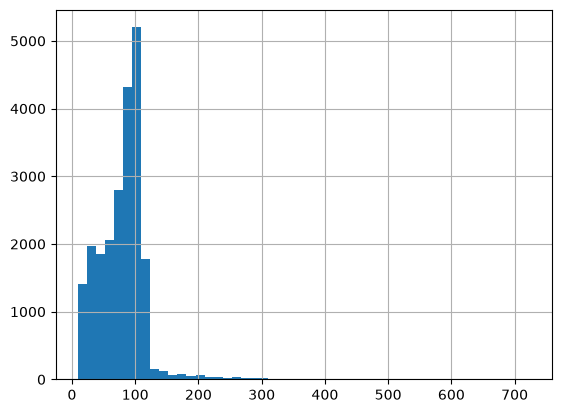

In [81]:
df["char_len"].hist(bins=50)

- самые короткие и самые длинные строки — проверить на аномалии:

In [82]:
print("Самые короткие строки:")
print(df.nsmallest(10, "char_len")[["id", "text"]])
print()
print("Самые длинные строки:")
print(df.nlargest(10, "char_len")[["id", "text"]])

Самые короткие строки:
                 id         text
1471  001471_RUSLAN   Хельсинки.
1374  001374_RUSLAN  Билета нет.
1653  001653_RUSLAN  Поздравляю!
1752  001752_RUSLAN  ВСЕ РУШИТСЯ
2076  002076_RUSLAN  Бесполезно.
2207  002207_RUSLAN  ВОЗВРАЩЕНИЕ
2370  002370_RUSLAN  КЛУБОК ЗМЕЙ
2391  002391_RUSLAN  Брал трубку
2769  002769_RUSLAN  Перепишите.
2783  002783_RUSLAN  Напечатали.

Самые длинные строки:
                  id  \
19766  019766_RUSLAN   
19767  019767_RUSLAN   
19655  019655_RUSLAN   
19685  019685_RUSLAN   
18863  018863_RUSLAN   
19147  019147_RUSLAN   
19419  019419_RUSLAN   
19581  019581_RUSLAN   
19669  019669_RUSLAN   
19068  019068_RUSLAN   

                                                                                                                          text  
19766  Как это получалось, как выходило, что вот иду я по улице – тучный, взрослый и даже временами в свою очередь нахальны...  
19767  Я говорю продавщице, женщине лет шестидесяти «Девушка, милень

### 2.1 Лишние пробелы

- множественные пробелы, пробелы в начале/конце строки

In [83]:
mask_double_space = df["text"].str.contains(r"  +", regex=True, na=False)
mask_edge_space = df["text"].str.contains(r"^\s|\s$", regex=True, na=False)

print(f"Строк с двойными пробелами: {mask_double_space.sum()}")
print(f"Строк с пробелами по краям: {mask_edge_space.sum()}")

Строк с двойными пробелами: 65
Строк с пробелами по краям: 15495


### 2.2 Юникод-нормализация (NFC/NFD)

- строки в разной юникод-нормализации визуально одинаковы, но сравниваются как разные. 
- приводить всё к NFC нужно явно.

In [84]:
mask_not_nfc = df["text"].apply(lambda t: unicodedata.normalize("NFC", str(t)) != str(t))
print(f"Строк не в NFC: {mask_not_nfc.sum()}")
if mask_not_nfc.sum() > 0:
    df.loc[mask_not_nfc, "text"].head(10).tolist()

Строк не в NFC: 0


### 2.3 Знак ударения (U+0301)

- **критично:** этот символ нельзя терять при нормализации — он размечает ударение для лабы 3. 
- проверяем, есть ли он в корпусе вообще.

In [85]:
mask_stress = df["text"].str.contains("\u0301", regex=False, na=False)
print(f"Строк со знаком ударения U+0301: {mask_stress.sum()}")
if mask_stress.sum() > 0:
    df.loc[mask_stress, "text"].head(10).tolist()

Строк со знаком ударения U+0301: 2


## 3. Поиск ненормализованных данных по категориям

- для каждой категории:  
маска regex → количество/доля строк → несколько примеров для ручной проверки.

### 3.1 Цифры

- плюс разбивка по подтипам (годы / десятичные / диапазоны / порядковые с точкой).

In [86]:
mask_digits = df["text"].str.contains(r"\d", regex=True, na=False)
print(f"Строк с цифрами: {mask_digits.sum()} ({mask_digits.mean():.2%})")
df.loc[mask_digits, "text"].sample(min(15, mask_digits.sum()), random_state=42).tolist()

Строк с цифрами: 4 (0.02%)


['На Филиппинах кто‑то застрелил руководителя партийной оппозиции. Под Мелитополем разбился «ТУ‑129». ',
 '– Турбовинтовой МИ‑6, – заметил Пупс, вставая. – Е‑ё! – лениво крикнул он. Затем скрестил над головой руки. ',
 'Брат разъезжал по отдаленным лагерным точкам. Ему предоставили казенную машину «ГАЗ‑61». ',
 'В сумочке ее лежало нечто, размером чуть поболее миниатюрного дамского браунинга «Элита‑16». ']

In [87]:
digit_subtypes = {
    "год (19xx/20xx)": r"\b(?:19|20)\d{2}\b",
    "десятичное число": r"\d+[.,]\d+",
    "диапазон чисел": r"\d+\s?-\s?\d+",
    "порядковое с точкой/суффиксом": r"\d+[-]?(?:й|я|е|го|му|\.)\b",
}

for name, pattern in digit_subtypes.items():
    m = df["text"].str.contains(pattern, regex=True, na=False)
    print(f"{name}: {m.sum()} строк")

год (19xx/20xx): 0 строк
десятичное число: 0 строк
диапазон чисел: 0 строк
порядковое с точкой/суффиксом: 0 строк


### 3.2 Некириллические буквы (латиница)

In [88]:
mask_latin = df["text"].str.contains(r"[A-Za-z]", regex=True, na=False)
print(f"Строк с латиницей: {mask_latin.sum()} ({mask_latin.mean():.2%})")
df.loc[mask_latin, "text"].sample(min(15, mask_latin.sum()), random_state=42).tolist()

Строк с латиницей: 0 (0.00%)


[]

### 3.3 Технические символы

In [89]:
mask_tech = df["text"].str.contains(r"[*/@+<>=_#\\^~]", regex=True, na=False)
print(f"Строк с техническими символами: {mask_tech.sum()} ({mask_tech.mean():.2%})")
df.loc[mask_tech, "text"].sample(min(15, mask_tech.sum()), random_state=42).tolist()

Строк с техническими символами: 5 (0.02%)


['А Лев Уфлянд* еще больше подливает желчи, плюет на русский народ.',
 '<Предисловие к книге Н.Сагаловского «Витязь в еврейской шкуре»> ',
 '/Например, вертухай, как вы соизволили дружески меня поименовать.',
 'Я на букву О /библиография к Окуджаве/.',
 'Не хочу демонстрировать своего превосходства… Мы будем выше этого. Ответим ей добром на зло… О чем ты думаешь/.. ']

### 3.4 Обозначения (%, °, $, валюты и т.п.)

In [90]:
mask_signs = df["text"].str.contains(r"[%°$€₽№&]", regex=True, na=False)
print(f"Строк с обозначениями: {mask_signs.sum()} ({mask_signs.mean():.2%})")
df.loc[mask_signs, "text"].sample(min(15, mask_signs.sum()), random_state=42).tolist()

Строк с обозначениями: 0 (0.00%)


[]

### 3.5 Сокращения

- чистый regex ловит только кандидатов (короткий токен с точкой не в конце предложения). 
- внутри много ложных срабатываний (инициалы вроде "А. С. Пушкин") — обязательна ручная проверка выборки.

In [91]:
mask_abbrev_candidates = df["text"].str.contains(r"\b[а-яё]{1,4}\.\s+[а-яё]", regex=True, na=False)
print(f"Кандидатов в сокращения: {mask_abbrev_candidates.sum()} ({mask_abbrev_candidates.mean():.2%})")
df.loc[mask_abbrev_candidates, "text"].sample(min(20, mask_abbrev_candidates.sum()), random_state=42).tolist()

Кандидатов в сокращения: 14 (0.06%)


['Вольдемар Хендрикович с профессиональной взыскательностью обращает внимание на то. как одеты персонажи. ',
 'Они – моя неврастения, злость, апломб, беспечность. И т. д. И самая кровавая война – бой призраков. ',
 'Что вам. собственно, нужно?',
 'Мне осталось добавить лишь несколько слов. двадцать третьего декабря тысяча девятьсот восемьдесят первого года в Нью‑Йорке родился мой сынок. ',
 'Впоследствии на Западе сшил. говорят, из них чехол для микроавтобуса..',
 'Я много слышала о здешних дизайнерах и живописцах. Кроме того. я люблю море… Вы путешествуете одна? ',
 'Это после того. как со мной заключили договор, выплатили мне гонорар и книга прошла весь издательский цикл.',
 'Уфлянда зовут Владимир прим. автора.',
 'Я вынужден признать, что кто‑то из нас может стать первой жертвой этого критерия, но от этого он не становится менее надежным, а главное – менее единственным, если так можно говорить по‑русски… Мы уже говорили две литературы или одна – это, по сути дела, разговор о будуще

In [92]:
known_abbrevs = ["г.", "ул.", "д.", "т.д.", "т.п.", "г-н", "г-жа", "им.", "пр.", "тов.", "проф.", "т.к.", "т.е."]

for a in known_abbrevs:
    cnt = df["text"].str.contains(rf"\b{re.escape(a)}", regex=True, na=False).sum()
    print(f"{a!r}: {cnt} строк")

'г.': 0 строк
'ул.': 1 строк
'д.': 2 строк
'т.д.': 0 строк
'т.п.': 0 строк
'г-н': 0 строк
'г-жа': 0 строк
'им.': 0 строк
'пр.': 0 строк
'тов.': 1 строк
'проф.': 0 строк
'т.к.': 0 строк
'т.е.': 0 строк


### 3.6 Необычные знаки препинания

три проверки: 
1. полная инвентаризация всех нестандартных символов корпуса, 
2. комбинации знаков подряд, 
3. парность кавычек/скобок.

In [93]:
standard_punct = set('.,!?;:"\'«»…—- \n\u0301')

def nonstandard_chars(text):
    return set(ch for ch in str(text) if not (ch.isalnum() or ch in standard_punct))

all_bad_chars = Counter()
for chars in df["text"].apply(nonstandard_chars):
    all_bad_chars.update(chars)

print("Все нестандартные символы корпуса и их частота:")
for ch, cnt in all_bad_chars.most_common(50):
    print(repr(ch), cnt)

Все нестандартные символы корпуса и их частота:
'–' 5491
'‑' 2006
'(' 293
')' 292
'„' 53
'“' 39
'”' 12
'’' 6
'/' 3
'*' 1
'<' 1
'>' 1


In [94]:
mask_punct_combo = df["text"].str.contains(r"[.!?]{2,}|[,]{2,}|[\"'«»]{2,}", regex=True, na=False)
print(f"Строк с подозрительными комбинациями пунктуации: {mask_punct_combo.sum()} ({mask_punct_combo.mean():.2%})")
df.loc[mask_punct_combo, "text"].sample(min(15, mask_punct_combo.sum()), random_state=42).tolist()

Строк с подозрительными комбинациями пунктуации: 989 (4.45%)


['Теряя сознание, Буш шептал Ликуйте, смерды! Зрю на ваших лицах грубое торжество плоти!.. ',
 '«Купила Марику на день рожденья тюлевые занавески – обалдеть!..» Так мы прожили года четыре. ',
 'Как‑то дождливым вечером мы с ним разговорились – Миша, ты любил свою жену? – Кому?! Жену‑то? Бабу, в смысле? ',
 '– Что же это получается? Я дочку второго секретаря Запорожского обкома тягал, а козу что, не имею права?.. ',
 'Стоило ради этого уезжать из Москвы?!',
 '– Вся моя жизнь – это борьба с цензурой, – говорил он, – любая цензура – издевательство над художником… Цензура вызывает у меня алкогольный протест!..',
 '– Боря! – орал я. – Что тебе прислать? Ты, наверное, в жутком состоянии?! Ты ведь убил человека! – Не кричи. ',
 'Неужели все это происходит со мной?!',
 'Разве можно такую гору прочесть?!',
 'Здесь, я вижу, тесновато. Пройдемте в следующий зал!..» Параллельно я слушал чужие экскурсии. ',
 '– Природа не окупается! Лернер возражал – Искусство не продается!.. На том они и рассталис

In [95]:
def unpaired_quotes(text):
    text = str(text)
    issues = []
    if text.count("«") != text.count("»"):
        issues.append("«»")
    if text.count('"') % 2 != 0:
        issues.append('"')
    return issues

mask_unpaired = df["text"].apply(lambda t: len(unpaired_quotes(t)) > 0)
print(f"Строк с непарными кавычками: {mask_unpaired.sum()}")
df.loc[mask_unpaired, "text"].sample(min(15, mask_unpaired.sum()), random_state=42).tolist()

Строк с непарными кавычками: 376


['«Володя не просто влюбился в меня, он напал на меня, это было нападение. ',
 'Я, между прочим, жил в Казахстане. Так казахи еще в сто раз хуже!..» Нью‑Йорк. ',
 'За это следует бить морду. Любому…» Я пытался что‑то объяснить Давиду Яковлевичу. ',
 'Затем он бегал в студию. Затем беседовал по телефону женским голосом «Кого вам надо?.. Нету Тарасевича. ',
 'Я укажу вам истинную могилу Пушкина, которую большевики скрывают от народа!» ',
 'В ходе переезда рождается леденящее душу наименование – скарб…» ',
 '„Я вас любил так искренне, так нежно… Миру крепостнических отношений противопоставил Александр Сергеевич этот вдохновенный гимн бескорыстия…»',
 'Отлично знаешь. Такой несимпатичный, в черных ботинках с коричневыми шнурками».) ',
 'Нет винта. Спектакль разваливается…» За ним возвышались кирпичные стены. Над головой тускло сияли блоки. ',
 'А именно, средствами пластики выразить – базедову болезнь». ',
 'Написано еще одно произведение о гражданской войне и революции – мы снова убеждаем

### 3.7 Аббревиатуры (читаются по буквам)

In [96]:
mask_caps = df["text"].str.contains(r"(?<!^)(?<!\. )\b[А-ЯЁ]{2,6}\b", regex=True, na=False)
print(f"Кандидатов в аббревиатуры (капс вне начала предложения): {mask_caps.sum()} ({mask_caps.mean():.2%})")
df.loc[mask_caps, "text"].sample(min(20, mask_caps.sum()), random_state=42).tolist()

Кандидатов в аббревиатуры (капс вне начала предложения): 218 (0.98%)


['Компромисс третий «Я ЧУВСТВУЮ СЕБЯ КАК ДОМА (Гости Таллинна). ',
 'Жора переучивается на «ТУ». Ему командировки опротивели. – Ну, а ты, старый пес? ',
 'Даже в тех случаях, когда сюжеты прозаика родились – как в повести «Иностранка» – собственно в США, изображал Довлатов не «американскую жизнь», а жизнь наших соотечественников в новых для них условиях диаспоры.',
 'Недавно московское радио передало драматическое сообщение корреспондента ТАСС из Нью‑Йорка. ',
 'ЛИТЕРАТУРНЫЙ ГАРЛЕМ',
 'И наконец – ОВИР, таможня, венские сосиски… Четыре года я живу в Америке. Опять мы вместе. ',
 'Пренебрежение соцреализмом. Группу подростков выгоняют из СХШ. Они работают и учатся самостоятельно. ',
 'Просто мы не знали, как это делается в США.',
 '«Справка дана (Ф.И.О.), выезжающему…» И неожиданная концовка «…на постоянное место жительства – в ОВИР». ',
 'Активисты ДОСААФ из Торжка. Без конца задавали вопросы. – Когда? В каком году? – Я думаю, в тридцатом. – За сколько? ',
 'Могу сказать, что заседания

**Важно:** капс не всегда аббревиатура для расшифровки — может быть имя собственное (МГУ, ГЭС, НАТО), которое как раз и звучит буквами. Проверить руками, какие из найденных реально требуют разворачивания.

### 3.8 Междометия

- регулярка тут работает плохо — задача словарная. 
- список ниже — стартовый набор.

In [97]:
interjections = ["угу", "ага", "ой", "эх", "ах", "ха-ха", "тсс", "фу", "ух", "ого"]
flexible_interj = [r"хм+", r"м{3,}", r"ыых*"]

all_patterns = interjections + flexible_interj
pattern = r"\b(?:" + "|".join(all_patterns) + r")\b"

mask_interj = df["text"].str.contains(pattern, regex=True, case=False, na=False)
print(f"Строк с междометиями: {mask_interj.sum()} ({mask_interj.mean():.2%})")

df.loc[mask_interj, "text"].sample(min(15, mask_interj.sum()), random_state=42).tolist()

Строк с междометиями: 64 (0.29%)


['Я прямо‑таки слышал его низкий доброжелательный голос «Ах вот ты какой! Ну, прямо вылитый Хемингуэй!..» ',
 '– Ого, – сказал Толстой, – а если бы здесь находился глаз?! Умер Алексей Толстой. Коллеги собрались на похороны. ',
 'Ага, подумают, возомнил себя непризнанным гением!',
 '– Как это – в лесу? – удивлялся я. – Действие происходит в штрафном изоляторе. – Ах да, – говорила тетка… ',
 'Ах, знает, и все-таки собирается писать о нем книгу?!',
 '– Ах да, я понимаю, понимаю, – лепетал турист… Ко дню моего приезда Стасик был изнурен недельным запоем. ',
 'Вы Шаблинский? Он в командировке. Ах да… Готовы? Вам через одного… Альтмяэ вынул папиросы. ',
 'Галина мальчишеским тенором выводила Эх, истомилась, устала я, Ночью и днем… Только о нем… ',
 '– Ах вот как?! Тогда я уеду в Америку! И уехал. На Западе Еселевский окончательно разочаровался в марксизме. ',
 '- Ты о чем? - спросил Григорий Борисович. - Ах, да... - Они не знают, где машина. - Так. Куда же она могла подеваться? ',
 'Вдруг от

### 3.9 Эмодзи

In [98]:
import regex

# классические (типа :-), =D, ^_^, ;() )
western_emoji = r"(?:[:;=8]['`]?[:-]?[()[\]{}DPOpPdS3oO0*X3xb])"

# скобочные шлейфы (типа )))), (((, мдасссс)
brackets_shorthand = r"[()]{2,}"

# азиатские и текстовые мемы (типа ¯\_(ツ)_/¯, t( -_- t) )
kaomoji_and_memes = r"(?:¯\\_\(ツ\)_/¯|\(._.\)|[tT]\(\s*[-_–—]+\s*[tT]\)|[-_–—\^][._0oO][-_–—\^])"

text_emoji_pattern = regex.compile(
    f"{western_emoji}|{brackets_shorthand}|{kaomoji_and_memes}"
)

mask_text_emoji = df["text"].apply(lambda t: bool(text_emoji_pattern.search(str(t))))
print(f"Строк с текстовыми смайликами: {mask_text_emoji.sum()} ({mask_text_emoji.mean():.2%})")
df.loc[mask_text_emoji, "text"].sample(min(15, mask_text_emoji.sum()), random_state=42).tolist()

Строк с текстовыми смайликами: 0 (0.00%)


[]

### 3.10 Буква ё, заменённая на е

- ищем слова, которые по словарю должны писаться через ё, но в тексте записаны через е.

In [99]:
%load_ext autoreload
%autoreload 2

import pandas as pd
from utils.yoficator import CustomYoficator

yo_tool = CustomYoficator()

results = df["text"].apply(yo_tool.check_text)

mask_yo_errors = results.apply(lambda x: x[0] == 1)
df_clean_texts = results.apply(lambda x: x[1])

print(f"Строк с найденными заменами е->ё: {mask_yo_errors.sum()} ({mask_yo_errors.mean():.2%})")

df.loc[mask_yo_errors, "text"].sample(min(15, mask_yo_errors.sum()), random_state=42).tolist()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Строк с найденными заменами е->ё: 4990 (22.48%)


['Рекомендовалось заменять ее фаршированной щукой. Меттер говорил презираемой им сотруднице ',
 'Убежден, что с некоторыми основаниями взялся за перо. Люди, которым он доверяет, готовы это засвидетельствовать. ',
 'Когда‑то, еще будучи аспирантом филфака, он напечатал статью. ',
 'Мы все его любили. Здорово, Фима! произнес я кощунственно бодрым голосом. ',
 'Я шел за этой женщиной до самой Лиговки. Как мне хотелось подарить ее Леньке самые дорогие игрушки. ',
 'О своих кулачных подвигах рассказывал часами. Причем довольно много фантазировал. ',
 'Таким образом, за пределами этой схемы оказывалось едва ли не все самое ценное, подлинно художественное и одухотворенное, все то, что десятилетиями искоренялось в советском государстве как идейно чуждое, проникнутое буржуазными настроениями, выражающее интересы кулачества и других реакционных слоев общества… Короче говоря, все то, что мы любим и ценим в русской литературе двадцатого столетия.',
 'Младший, Леопольд, с детства шел иным, более на

## 4. Пересечение категорий

- сколько строк попадают сразу в несколько категорий — влияет на порядок применения правил normalizer/filter.

In [100]:
masks = {
    "Цифры": mask_digits,
    "Латиница": mask_latin,
    "Техсимволы": mask_tech,
    "Обозначения": mask_signs,
    "Сокращения (кандидаты)": mask_abbrev_candidates,
    "Пунктуация: комбо": mask_punct_combo,
    "Пунктуация: непарные кавычки": mask_unpaired,
    "Аббревиатуры (капс)": mask_caps,
    "Междометия": mask_interj,
    "Эмодзи": mask_emoji,
}

overlap = pd.DataFrame(
    [[  (m1 & m2).sum() for m2 in masks.values()] for m1 in masks.values()],
    index=masks.keys(),
    columns=masks.keys(),
)
overlap

,Цифры,Латиница,Техсимволы,Обозначения,Сокращения (кандидаты),Пунктуация: комбо,Пунктуация: непарные кавычки,Аббревиатуры (капс),Междометия,Эмодзи
Цифры,4,0,0,0,0,0,0,3,0,0
Латиница,0,0,0,0,0,0,0,0,0,0
Техсимволы,0,0,5,0,0,1,0,0,0,0
Обозначения,0,0,0,0,0,0,0,0,0,0
Сокращения (кандидаты),0,0,0,0,14,2,1,0,0,0
Пунктуация: комбо,0,0,1,0,2,989,36,8,13,0
Пунктуация: непарные кавычки,0,0,0,0,1,36,376,9,2,0
Аббревиатуры (капс),3,0,0,0,0,8,9,218,1,0
Междометия,0,0,0,0,0,13,2,1,64,0
Эмодзи,0,0,0,0,0,0,0,0,0,0


## 5. Сводная таблица по корпусу

- итоговая статистика по всем категориям
- доля строк, у которых сработала хотя бы одна проблема (потенциальная верхняя граница того, что отфильтрует `text_filter`).

In [101]:
summary = pd.DataFrame({
    "Категория": list(masks.keys()),
    "Количество строк": [m.sum() for m in masks.values()],
    "Доля от корпуса": [f"{m.mean():.2%}" for m in masks.values()],
})
summary

,Категория,Количество строк,Доля от корпуса
0,Цифры,4,0.02%
1,Латиница,0,0.00%
2,Техсимволы,5,0.02%
3,Обозначения,0,0.00%
4,Сокращения (кандидаты),14,0.06%
5,Пунктуация: комбо,989,4.45%
6,Пунктуация: непарные кавычки,376,1.69%
7,Аббревиатуры (капс),218,0.98%
8,Междометия,64,0.29%
9,Эмодзи,0,0.00%


In [102]:
any_problem = pd.concat(masks.values(), axis=1).any(axis=1)
print(f"Строк хотя бы с одной проблемой: {any_problem.sum()} ({any_problem.mean():.2%})")
print(f"Строк без проблем (по текущим правилам): {(~any_problem).sum()} ({(~any_problem).mean():.2%})")

Строк хотя бы с одной проблемой: 1597 (7.19%)
Строк без проблем (по текущим правилам): 20603 (92.81%)


## 6. Выводы

*(заполнить по результатам запуска на реальных данных и ручного просмотра выборок)*

По каждой категории:
- Реальная (проверенная руками) доля проблемных строк vs грубая regex-оценка
- Что относится к ложным срабатываниям (например, инициалы в сокращениях, имена собственные в капсе)

Итоговое распределение по модулям:
- **В `text_normalizer` (безопасные правки, не меняют состав слов):** пунктуация, юникод-варианты символов, лишние пробелы, NFC-нормализация, ё-фикация, удаление явного мусора (техсимволы, эмодзи)
- **В `text_filter` (word-changing, только отбраковка):** цифры/числительные, обозначения (%, °, $), реальные сокращения, аббревиатуры, междометия, необработанная латиница